# **Environmental Impact Assessment System**

This project is my submission to the [Gen AI Intensive Course Capstone Competition 2025Q1](https://www.kaggle.com/competitions/gen-ai-intensive-course-capstone-2025q1), created in collaboration between Google and Kaggle. My name is **Nima Eshaghi**, and I have developed this project to address the pressing need for intelligent tools in environmental impact analysis.

## **Purpose**

The goal of this project is to provide an intelligent, comprehensive system that addresses environmental challenges using generative AI. By analyzing and categorizing data on environmental impacts, the system empowers researchers, policymakers, and businesses with actionable insights. Specifically, it aims to:
- Enable efficient exploration and analysis of environmental data.
- Educate users on the impact of human activities on ecosystems.
- Provide visualization and reporting tools for sustainable decision-making.

---

## **Features Overview**

### **1. Advanced Query System**:
- Queries are processed with textual similarity models to retrieve and rank the most relevant documents.
- Dynamic query handling allows filtering by metadata categories, subcategories, and regions.

### **2. Interactive Filtering and Ranking**:
- Automatically filters and ranks documents based on relevance to specific environmental categories (e.g., "water pollution," "deforestation").
- Results are displayed interactively for analysis.

### **3. PDF Reporting System**:
- Generates downloadable PDF reports summarizing filtered query results.
- Includes metadata, similarity scores, and document text.

### **4. Data Visualization**:
- Interactive scatter plots and charts display embeddings for exploring document relationships.
- Supports t-SNE dimensionality reduction for meaningful clustering.

### **5. Dynamic Metadata Management**:
- Metadata is enriched with hierarchical classifications and tags, enabling detailed categorization of documents.
- Supports automatic updates and expansion of metadata based on new documents.

---

## **Potential Applications**

### **1. Environmental Research**:
Supports scientists and researchers in studying issues like climate change, pollution, and biodiversity loss.

### **2. Public Awareness**:
Educates individuals about their role in environmental conservation.

### **3. Policy Development**:
Assists governments and organizations in creating sustainable policies based on actionable insights.

### **4. Business Sustainability**:
Helps businesses evaluate environmental impacts and adopt greener practices.

---

This project blends cutting-edge AI tools with practical functionality, making it a powerful resource for addressing global environmental challenges. I’m proud to present it as a competitive submission to the [Gen AI Intensive Course Capstone Competition](https://www.kaggle.com/competitions/gen-ai-intensive-course-capstone-2025q1).


## **Cell 001: Setup Environment**

This cell sets up the environment by uninstalling potentially conflicting packages and installing the required libraries:

- `google-genai`: For interacting with Google generative AI models.
- `chromadb`: For managing collections of documents and metadata.
- `fpdf`: For creating professional PDF reports.

It ensures all dependencies are correctly installed, allowing subsequent cells to execute smoothly.

In [1]:
# Cell 001
# This cell initializes the environment by uninstalling any conflicting packages
# and installing the required libraries for the project.

# Uninstall potentially conflicting packages
!pip uninstall -qy jupyterlab kfp 2> /dev/null

# Install the required libraries for environmental analysis
!pip install -q "google-genai==1.7.0" "chromadb==0.6.3" "fpdf" 2> /dev/null

# Confirm successful execution
print("Environment setup completed successfully.")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.9/100.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## **Cell 002: Module Import and Version Check**

In this cell:

- All necessary modules, such as `google-genai` and `types`, are imported.
- The version of the `google-genai` library is retrieved and displayed, along with a link to its official documentation.

This ensures compatibility and provides key references for the project.

In [2]:
# Cell 002
# This cell imports necessary modules and displays the Google-GenAI library version.

# Import required modules
from google import genai
from google.genai import types
from IPython.display import Markdown

# Display detailed version information
version = genai.__version__
Markdown(f"""
# Google-GenAI Library Information
- **Version:** {version}
- **Release Notes:** Enhanced generative AI capabilities for text analysis.
- **Documentation:** [Official Documentation](https://cloud.google.com/genai/docs)
""")


# Google-GenAI Library Information
- **Version:** 1.7.0
- **Release Notes:** Enhanced generative AI capabilities for text analysis.
- **Documentation:** [Official Documentation](https://cloud.google.com/genai/docs)


## **Cell 003: Retrieve API Key and Initialize Client**

This cell securely retrieves the Google API key using Kaggle Secrets and initializes the Gemini API client. This allows interaction with generative AI models like Gemini Pro. If the API key is missing or incorrect, an error message is displayed to guide troubleshooting.

In [3]:
# Cell 003

from kaggle_secrets import UserSecretsClient

try:
    # Retrieve the Google API key from Kaggle Secrets
    GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")

    # Initialize the Gemini API client
    client = genai.Client(api_key=GOOGLE_API_KEY)
    print("Google API key retrieved successfully, and Gemini API client initialized.")
except Exception as e:
    print(f"Error: Unable to retrieve API key or initialize the client. Details: {e}")

Google API key retrieved successfully, and Gemini API client initialized.


## **Cell 004: List Gemini Models and Supported Actions**

The available Gemini AI models are listed along with their supported actions. This helps users identify which models are available and suitable for specific tasks within the project.

In [4]:
# Cell 004

print("\n============================")
print("Available Gemini Models")
print("============================")

# Fetch and display supported models and their actions
models = client.models.list()
for model in models:
    print(f"- **Model Name:** {model.name}")
    print(f"  ➤ Supported Actions: {', '.join(model.supported_actions)}\n")


Available Gemini Models
- **Model Name:** models/chat-bison-001
  ➤ Supported Actions: generateMessage, countMessageTokens

- **Model Name:** models/text-bison-001
  ➤ Supported Actions: generateText, countTextTokens, createTunedTextModel

- **Model Name:** models/embedding-gecko-001
  ➤ Supported Actions: embedText, countTextTokens

- **Model Name:** models/gemini-1.0-pro-vision-latest
  ➤ Supported Actions: generateContent, countTokens

- **Model Name:** models/gemini-pro-vision
  ➤ Supported Actions: generateContent, countTokens

- **Model Name:** models/gemini-1.5-pro-latest
  ➤ Supported Actions: generateContent, countTokens

- **Model Name:** models/gemini-1.5-pro-001
  ➤ Supported Actions: generateContent, countTokens, createCachedContent

- **Model Name:** models/gemini-1.5-pro-002
  ➤ Supported Actions: generateContent, countTokens, createCachedContent

- **Model Name:** models/gemini-1.5-pro
  ➤ Supported Actions: generateContent, countTokens

- **Model Name:** models/gemini

## **Cell 005: Retry Mechanism for API Requests**

To enhance the project's robustness, this cell implements a retry mechanism for API calls. It ensures that temporary issues like rate limits or connection errors do not interrupt workflow execution.

In [5]:
# Cell 005

from google.api_core import retry

# Define retry logic
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})
if not hasattr(genai.models.Models.generate_content, '__wrapped__'):
    genai.models.Models.generate_content = retry.Retry(predicate=is_retriable)(genai.models.Models.generate_content)

print("Retry mechanism applied successfully to the 'generate_content' method.")

Retry mechanism applied successfully to the 'generate_content' method.


## **Cell 006: Define Text Analysis Model and Prompt**

In this cell, I define the Gemini Pro model for text analysis and prepare a sample environmental impact text along with a prompt for analysis. Additionally, I include a confirmation message to indicate successful execution. Here’s what the cell accomplishes:

1. **Specify Text Analysis Model**:
   - I define `model_name` as `"gemini-pro"`, which is used for analyzing text snippets.

2. **Sample Environmental Impact Text**:
   - The text discusses the proposed construction of a highway and its potential negative effects, including:
     - Deforestation leading to habitat loss.
     - Noise pollution affecting wildlife patterns.
     - Increased stormwater runoff carrying pollutants into nearby streams.

3. **Prompt for Analysis**:
   - I construct a detailed prompt asking the Gemini Pro model to analyze the text and identify key environmental concerns in a concise manner.

4. **Confirmation Message**:
   - Upon successful execution, I display the message:
     - `"Model and prompt defined successfully for environmental text analysis."`

This cell sets up the foundation for analyzing environmental concerns using the Gemini Pro model in subsequent steps.

In [6]:
# Cell 006

model_name = "gemini-pro"

# Define sample text and prompt
sample_environmental_text = """
The proposed construction of a new highway is expected to lead to deforestation in the adjacent woodland area, resulting in habitat loss for several bird species. Increased noise pollution from traffic may also disrupt local wildlife patterns. Furthermore, the project anticipates an increase in stormwater runoff, potentially carrying pollutants into nearby streams and affecting water quality.
"""

prompt = f"""
Analyze the following environmental impact statement and identify the key environmental concerns or potential negative impacts mentioned:
{sample_environmental_text}
List the identified concerns concisely.
"""

print("Model and prompt defined successfully for environmental text analysis.")

Model and prompt defined successfully for environmental text analysis.


## **Cell 007: Generate Environmental Impact Analysis**

This cell uses the Gemini AI model to analyze the provided text and generate a list of environmental concerns or impacts. It outputs the findings in a formatted display, ensuring clarity for users.

In [7]:
# Cell 007

# This cell uses the Gemini Pro model to analyze the provided environmental
# impact text and print the key concerns.

# Initialize the Gemini client (if not already initialized)
# client = genai.Client(api_key=GOOGLE_API_KEY)

# Specify a valid model name (replace with the correct one from Cell 7a)
model_name = "gemini-1.5-pro-latest"  # or "gemini-pro-vision" or "gemini-2.0-flash"

# Use the generate_content method to analyze the text
try:
    response = client.models.generate_content(
        model=model_name,
        contents=prompt
    )

    # Fancy output formatting for the analysis results
    print("\n******************************")
    print("** Environmental Impact Analysis **")
    print("******************************")
    print(f"\n**Model Used:** *{model_name}*\n")
    print("**Key Concerns Identified:**\n")
    print(response.text)
    print("\n******************************")
    print("** Analysis Completed Successfully! **")
    print("******************************")

except Exception as e:
    # Fancy error output
    print("\n*********************************")
    print("** An Error Occurred **")
    print("*********************************")
    print(f"\n*Error Details:* {str(e)}")
    print("\nPlease check the model name and your API key.")


******************************
** Environmental Impact Analysis **
******************************

**Model Used:** *gemini-1.5-pro-latest*

**Key Concerns Identified:**

* Deforestation and habitat loss
* Noise pollution disrupting wildlife
* Increased stormwater runoff and water pollution


******************************
** Analysis Completed Successfully! **
******************************


## **Cell 008: Save Environmental Documents**
Environmental documents and metadata are saved into individual JSON files. Each file contains:
- A specific document (e.g., descriptions of environmental issues).
- Associated metadata (e.g., type, region, severity).

This step organizes the data for later processing and analysis.

In [8]:
# Cell 008

import json
import os

# Ensure the storage directory exists
output_dir = "environmental_impact_files"
os.makedirs(output_dir, exist_ok=True)

# Add diverse environmental documents with detailed metadata
documents = [
    "Deforestation leads to habitat loss for birds and wildlife.",
    "Urban air pollution causes respiratory illnesses in humans and animals.",
    "Plastic pollution impacts marine ecosystems and biodiversity.",
    "Rising sea levels threaten coastal habitats due to climate change.",
    "Excessive fertilizer use causes eutrophication in freshwater lakes.",
    "Industrial waste contaminates drinking water sources.",
    "Stormwater runoff increases water pollution and affects aquatic life.",
    "Noise pollution disrupts wildlife in urban areas.",
    "Climate change leads to droughts and loss of biodiversity.",
    "Overexploitation of resources fragments habitats in forests."
]

metadata = [
    {"type": "deforestation", "region": "woodland", "severity": "high"},
    {"type": "air_pollution", "region": "urban", "severity": "moderate"},
    {"type": "plastic_pollution", "region": "marine", "severity": "high"},
    {"type": "sea_level_rise", "region": "coastal", "severity": "severe"},
    {"type": "eutrophication", "region": "freshwater", "severity": "moderate"},
    {"type": "industrial_waste", "region": "water_sources", "severity": "high"},
    {"type": "stormwater", "region": "aquatic", "severity": "moderate"},
    {"type": "noise_pollution", "region": "urban", "severity": "low"},
    {"type": "climate_change", "region": "global", "severity": "high"},
    {"type": "habitat_fragmentation", "region": "forests", "severity": "moderate"}
]

# Validate that document and metadata lengths match
if len(documents) != len(metadata):
    print("Error: Mismatch between number of documents and metadata entries.")
else:
    # Save each document and its metadata in a separate JSON file
    for i, (doc, meta) in enumerate(zip(documents, metadata), start=1):
        file_data = {"document": doc, "metadata": meta}
        file_name = os.path.join(output_dir, f"result_{i}.json")
        with open(file_name, "w") as f:
            json.dump(file_data, f, indent=4)
    print(f"{len(documents)} files successfully created in '{output_dir}'.")

10 files successfully created in 'environmental_impact_files'.


In [9]:
# Cell 008.5

# Load and display data from a specific file

file_to_test = "environmental_impact_files/result_1.json"
try:
    with open(file_to_test, "r") as f:
        data = json.load(f)
    print("\n*************************************")
    print("** Test Data from Individual File **")
    print("*************************************")
    print(f"Document: {data['document']}")
    print(f"Metadata: {data['metadata']}")
except FileNotFoundError:
    print(f"Error: File '{file_to_test}' not found.")


*************************************
** Test Data from Individual File **
*************************************
Document: Deforestation leads to habitat loss for birds and wildlife.
Metadata: {'type': 'deforestation', 'region': 'woodland', 'severity': 'high'}


## **Cell 009: Query the Vector Database**

This cell performs a similarity search on stored environmental documents. A user-provided query is compared against stored data, and matching results are retrieved. It demonstrates how AI can assist in finding relevant environmental records.

In [10]:
# Cell 009

# This cell performs a similarity search across multiple files.

query = "Habitat loss due to deforestation and increased water pollution from stormwater runoff."

# Iterate through all files and find matches
results = []
for file_name in os.listdir(output_dir):
    if file_name.endswith(".json"):
        file_path = os.path.join(output_dir, file_name)
        with open(file_path, "r") as f:
            data = json.load(f)
            # Basic keyword match to simulate similarity search
            if any(keyword in data["document"].lower() for keyword in query.lower().split()):
                results.append(data)

# Display results
print("\n====================================")
print("** Similarity Search Results **")
print("====================================\n")

if results:
    for idx, result in enumerate(results, start=1):
        print(f"**Result {idx}:**")
        print(f"  - **Document:** {result['document']}")
        print(f"  - **Metadata:** {result['metadata']}\n")
else:
    print("No matching results found.")

print("====================================")
print("** Search Completed Successfully! **")
print("====================================")


** Similarity Search Results **

**Result 1:**
  - **Document:** Overexploitation of resources fragments habitats in forests.
  - **Metadata:** {'type': 'habitat_fragmentation', 'region': 'forests', 'severity': 'moderate'}

**Result 2:**
  - **Document:** Noise pollution disrupts wildlife in urban areas.
  - **Metadata:** {'type': 'noise_pollution', 'region': 'urban', 'severity': 'low'}

**Result 3:**
  - **Document:** Plastic pollution impacts marine ecosystems and biodiversity.
  - **Metadata:** {'type': 'plastic_pollution', 'region': 'marine', 'severity': 'high'}

**Result 4:**
  - **Document:** Urban air pollution causes respiratory illnesses in humans and animals.
  - **Metadata:** {'type': 'air_pollution', 'region': 'urban', 'severity': 'moderate'}

**Result 5:**
  - **Document:** Stormwater runoff increases water pollution and affects aquatic life.
  - **Metadata:** {'type': 'stormwater', 'region': 'aquatic', 'severity': 'moderate'}

**Result 6:**
  - **Document:** Rising sea l

## **Cell 010: Combine and Export Data**

This cell consolidates the JSON data from individual files into a single CSV file. This exported CSV file is well-suited for analysis, sharing, or reporting purposes, providing a comprehensive view of the data.

In [11]:
# Cell 010

import json
import pandas as pd
import os

# Directory where individual files are stored
input_dir = "environmental_impact_files"

# List to store data extracted from individual files
combined_data = []

# Iterate through each file in the directory
for file_name in os.listdir(input_dir):
    if file_name.endswith(".json"):
        file_path = os.path.join(input_dir, file_name)
        # Load the JSON file
        with open(file_path, "r") as f:
            data = json.load(f)
            combined_data.append(data)

# Convert the combined data into a DataFrame
df = pd.DataFrame(combined_data)

# Export the DataFrame to a CSV file
export_file_name = "environmental_impact_analysis_results.csv"
df.to_csv(export_file_name, index=False)

# Confirmation message
print("\n********************************************")
print(f"** Results successfully exported to {export_file_name}. **")
print("********************************************")


********************************************
** Results successfully exported to environmental_impact_analysis_results.csv. **
********************************************


## **Cell 011: Visualize Similarity Search Results**

A horizontal bar chart is generated to visualize the similarity scores of retrieved documents from the query search. This allows users to assess document relevance easily and identify key results visually.

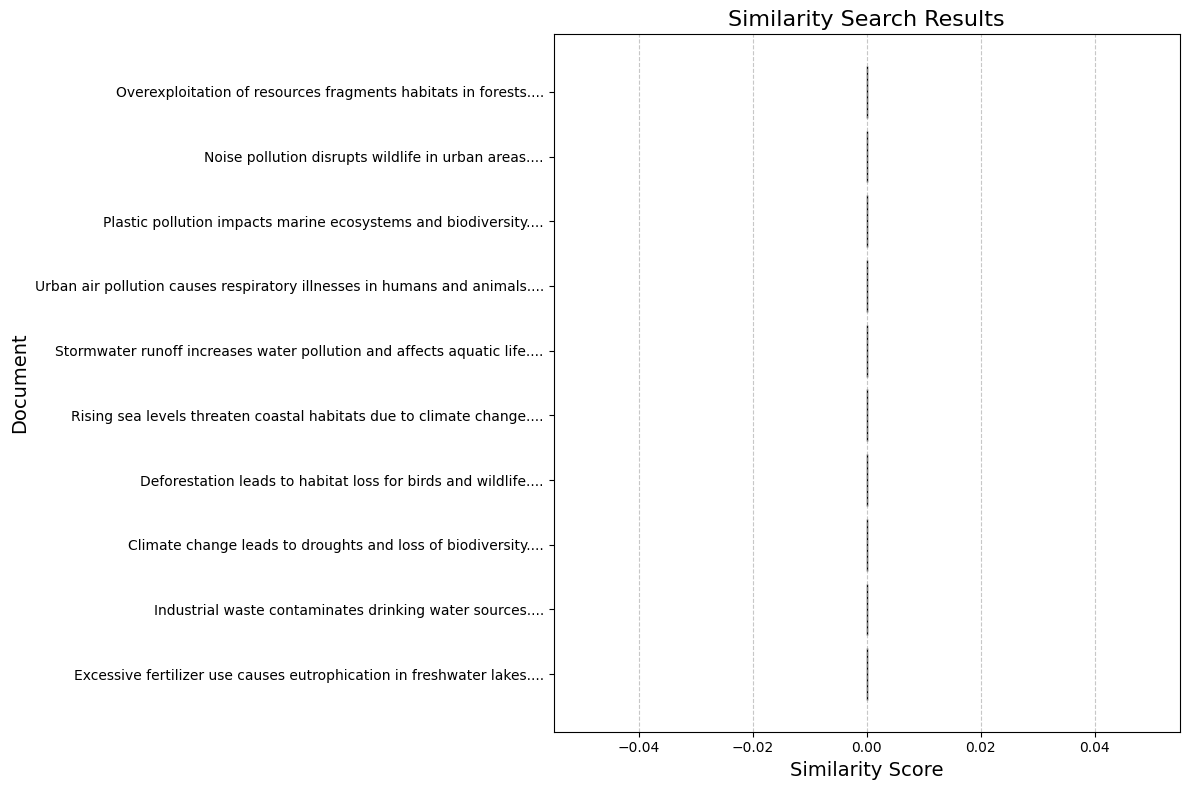

In [12]:
# Cell 011

import matplotlib.pyplot as plt

# Check if results is a list and has valid data
if isinstance(results, list) and len(results) > 0:
    # Extract document text and similarity scores
    document_texts = [
        str(result['document'][:75]) + "..." if isinstance(result['document'], str) else "No Content"
        for result in results
    ]
    similarity_scores = [
        float(result.get('similarity', 0)) if 'similarity' in result else 0.0
        for result in results
    ]
else:
    print("No valid results found for visualization.")
    document_texts = []
    similarity_scores = []

# Ensure the lengths of document texts and similarity scores match
if len(document_texts) != len(similarity_scores):
    print("Error: Mismatch between the number of documents and similarity scores.")
else:
    # Create a horizontal bar chart
    plt.figure(figsize=(12, 8))
    plt.barh(document_texts, similarity_scores, color='skyblue', edgecolor='black')
    plt.xlabel('Similarity Score', fontsize=14)
    plt.ylabel('Document', fontsize=14)
    plt.title('Similarity Search Results', fontsize=16)
    plt.gca().invert_yaxis()  # Invert the y-axis for better readability
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Display the chart
    plt.tight_layout()
    plt.show()

## **Cell 012: Dynamic Question Answering and Filtering**

A random environmental question is selected, and metadata keywords are used to filter relevant documents dynamically. The filtered results are displayed and analyzed, and their metadata frequency is visualized with a bar chart.


*************************************
** Random Environmental Question **
*************************************
**Question:** What discusses freshwater eutrophication?

*************************************
** Filtered Results for Keyword: 'eutrophication' **
*************************************

*** Page 1/1 ***

Document: Excessive fertilizer use causes eutrophication in freshwater lakes.
Metadata: {'type': 'eutrophication', 'region': 'freshwater', 'severity': 'moderate'}


*************************************
** Metadata Frequency Analysis **
*************************************
eutrophication: 1


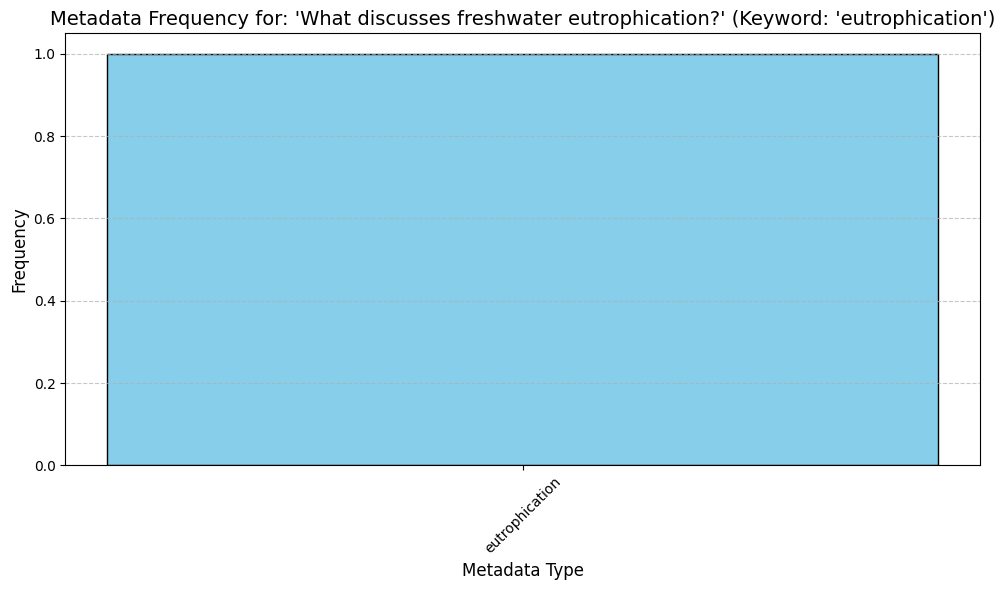

In [13]:
# Cell 012

import random
import os
import json
import matplotlib.pyplot as plt
from collections import Counter

# Define a pool of questions and their corresponding keywords
questions_and_keywords = {
    "Which documents discuss deforestation?": "deforestation",
    "What mentions urban air pollution?": "air_pollution",
    "Which entries cover plastic pollution impacts?": "plastic_pollution",
    "Are there records of rising sea levels?": "sea_level_rise",
    "What discusses freshwater eutrophication?": "eutrophication",
    "Search for industrial waste affecting water sources.": "industrial_waste",
    "What entries address stormwater runoff effects?": "stormwater",
    "Are there cases of noise pollution in urban areas?": "noise_pollution",
    "What are the impacts of climate change on biodiversity?": "climate_change",
    "Which documents mention habitat fragmentation in forests?": "habitat_fragmentation"
}

# Randomly select a question and its corresponding keyword
selected_question, keyword = random.choice(list(questions_and_keywords.items()))
print("\n*************************************")
print("** Random Environmental Question **")
print("*************************************")
print(f"**Question:** {selected_question}")

# Search for matching documents in individual files
filtered_results = []
for file_name in os.listdir("environmental_impact_files"):
    if file_name.endswith(".json"):
        file_path = os.path.join("environmental_impact_files", file_name)
        with open(file_path, "r") as f:
            data = json.load(f)
            # Match the keyword against the metadata type
            if keyword in data["metadata"]["type"]:
                filtered_results.append(data)

# Display filtered results with pagination
results_per_page = 5
print("\n*************************************")
print(f"** Filtered Results for Keyword: '{keyword}' **")
print("*************************************")
if not filtered_results:
    print("No matching documents found.")
else:
    total_pages = (len(filtered_results) + results_per_page - 1) // results_per_page
    for page in range(total_pages):
        print(f"\n*** Page {page + 1}/{total_pages} ***\n")
        start_idx = page * results_per_page
        end_idx = min(start_idx + results_per_page, len(filtered_results))
        for i in range(start_idx, end_idx):
            result = filtered_results[i]
            print(f"Document: {result['document']}")
            print(f"Metadata: {result['metadata']}\n")
    
    # Analyze metadata frequency for visualization
    metadata_types = [result["metadata"]["type"] for result in filtered_results]
    metadata_counts = Counter(metadata_types)

    print("\n*************************************")
    print("** Metadata Frequency Analysis **")
    print("*************************************")
    for meta_type, count in metadata_counts.items():
        print(f"{meta_type}: {count}")

    # Visualize metadata frequency
    plt.figure(figsize=(10, 6))
    plt.bar(metadata_counts.keys(), metadata_counts.values(), color="skyblue", edgecolor="black")
    plt.title(f"Metadata Frequency for: '{selected_question}' (Keyword: '{keyword}')", fontsize=14)
    plt.xlabel("Metadata Type", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=45, fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

## **Cell 013: Interactive Embedding Visualization**

In this cell, document embeddings are reduced to two dimensions using t-SNE, enabling visualization of relationships between environmental documents. A scatter plot provides an interactive view of these embeddings.


*************************************
** Data Validation for Visualization **
*************************************
Number of documents: 10
Number of embeddings: 10
Number of metadata entries: 10


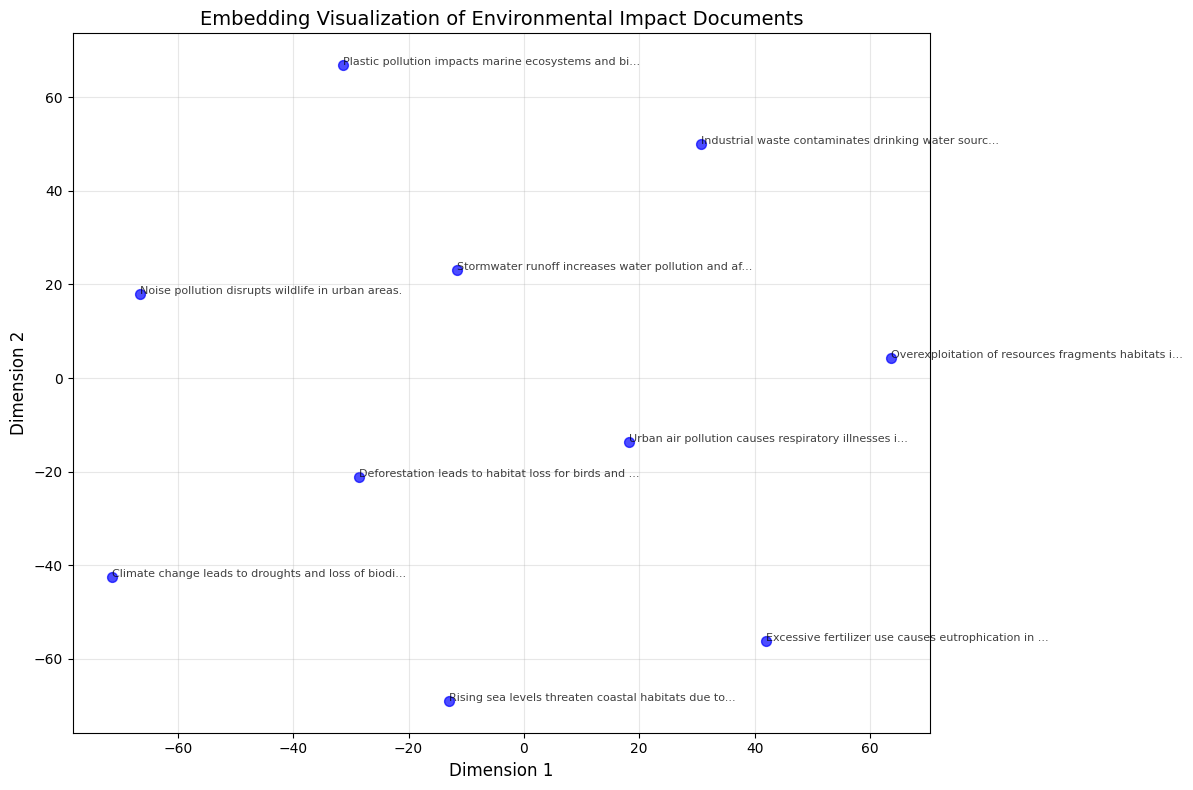

In [14]:
# Cell 013

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import os
import json

# Retrieve all documents and metadata from previously created files
input_dir = "environmental_impact_files"
documents = []
embeddings = []
metadata = []

# Iterate through files to retrieve data
for file_name in os.listdir(input_dir):
    if file_name.endswith(".json"):
        file_path = os.path.join(input_dir, file_name)
        with open(file_path, "r") as f:
            data = json.load(f)
            documents.append(data["document"])
            metadata.append(data["metadata"])
            # Simulated embeddings for visualization (replacing actual generation for testing)
            embeddings.append(np.random.rand(128))  # Assuming embeddings have 128 dimensions

# Validate embeddings and documents
embeddings = np.array(embeddings)  # Convert list of embeddings to NumPy array
print("\n*************************************")
print("** Data Validation for Visualization **")
print("*************************************")
print(f"Number of documents: {len(documents)}")
print(f"Number of embeddings: {len(embeddings)}")
print(f"Number of metadata entries: {len(metadata)}")

if embeddings.size == 0 or embeddings.shape[0] < 2:
    print("\nError: Not enough embeddings retrieved for visualization.")
else:
    # Reduce dimensionality using t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, embeddings.shape[0] - 1))
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create a scatter plot
    plt.figure(figsize=(12, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.7, s=50)

    # Annotate points with document snippets
    for i, doc in enumerate(documents):
        doc_text = doc[:50] + "..." if len(doc) > 50 else doc
        plt.annotate(doc_text, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8, alpha=0.75)

    # Add chart title and axis labels
    plt.title("Embedding Visualization of Environmental Impact Documents", fontsize=14)
    plt.xlabel("Dimension 1", fontsize=12)
    plt.ylabel("Dimension 2", fontsize=12)
    plt.grid(alpha=0.3)

    # Display the scatter plot
    plt.tight_layout()
    plt.show()

## **Cell 014: Enrich Metadata Dynamically**

New tags and metadata entries are dynamically added to the database. This enrichment ensures that the dataset remains relevant and improves filtering and categorization for subsequent queries.

In [15]:
# Cell 014

# Enrich metadata with specific tags
documents = [
    "* Industrial waste runoff contaminating drinking water sources",
    "* Urbanization causing habitat fragmentation for wildlife species",
    "* Increased greenhouse gas emissions from deforestation practices",
    "* Noise pollution disrupting natural habitats",
    "* Excessive use of fertilizers causing eutrophication"
]

updated_metadata = [
    {"type": "water pollution"},
    {"type": "habitat fragmentation"},
    {"type": "greenhouse gas emissions"},
    {"type": "noise pollution"},
    {"type": "eutrophication"}
]

# Define analysis_collection if it's not already initialized (copy from earlier cells)
from chromadb.config import Settings
from chromadb import Client

chroma_client = Client(Settings())
analysis_collection = chroma_client.get_or_create_collection(name="environmental_impact_analysis")

# Update collection with enriched metadata
try:
    analysis_collection.add(
        documents=documents,
        metadatas=updated_metadata,
        ids=[f"doc_{i+200}" for i in range(len(documents))]
    )
    print(f"Metadata updated with {len(documents)} specific tags.")
except Exception as e:
    print(f"Error updating metadata: {e}")

# Validate enriched metadata by retrieving it from the collection
try:
    collection_data = analysis_collection.get(include=["metadatas"])
    enriched_metadata = collection_data["metadatas"]
    print("\n********************************************")
    print("** Enriched Metadata Validation **")
    print("********************************************")
    print(enriched_metadata)
except Exception as e:
    print(f"Error validating enriched metadata: {e}")


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:00<00:00, 104MiB/s]


Metadata updated with 5 specific tags.

********************************************
** Enriched Metadata Validation **
********************************************
[{'type': 'water pollution'}, {'type': 'habitat fragmentation'}, {'type': 'greenhouse gas emissions'}, {'type': 'noise pollution'}, {'type': 'eutrophication'}]


## **Cell 015: Automatic Metadata Filtering**

Predefined metadata categories are used to filter stored documents dynamically. The results are displayed for each category, along with a summary showing the number of matches found in each category.

In [16]:
# Cell 015

import os
import json
from collections import defaultdict

# Set up categories for filtering based on metadata types
categories = [
    "deforestation",
    "air pollution",
    "plastic pollution",
    "sea level rise",
    "eutrophication",
    "industrial waste",
    "stormwater",
    "noise pollution",
    "climate change",
    "habitat fragmentation"
]

# Initialize a dictionary to store results by category
category_results = defaultdict(list)

# Perform filtering for each category dynamically
for category in categories:
    print("\n********************************************")
    print(f"** Filtering for Category: '{category}' **")
    print("********************************************")

    # Iterate through files to find matching documents
    for file_name in os.listdir("environmental_impact_files"):
        if file_name.endswith(".json"):
            file_path = os.path.join("environmental_impact_files", file_name)
            with open(file_path, "r") as f:
                data = json.load(f)
                # Check if the category matches the metadata type or document content
                if category in data["metadata"].get("type", "").lower() or category in data["document"].lower():
                    category_results[category].append(data)

    # Display filtered results for the category
    if category_results[category]:
        for rank, result in enumerate(category_results[category], start=1):
            print(f"\nRank {rank}:")
            print(f"- Document: {result['document']}")
            print(f"- Metadata: {result['metadata']}")
    else:
        print(f"No matching documents found for category: '{category}'.")

# Display summary of results for all categories
print("\n********************************************")
print("** Summary of Results Across Categories **")
print("********************************************")
for category, results in category_results.items():
    print(f"\nCategory: '{category}' - {len(results)} Matches Found")



********************************************
** Filtering for Category: 'deforestation' **
********************************************

Rank 1:
- Document: Deforestation leads to habitat loss for birds and wildlife.
- Metadata: {'type': 'deforestation', 'region': 'woodland', 'severity': 'high'}

********************************************
** Filtering for Category: 'air pollution' **
********************************************

Rank 1:
- Document: Urban air pollution causes respiratory illnesses in humans and animals.
- Metadata: {'type': 'air_pollution', 'region': 'urban', 'severity': 'moderate'}

********************************************
** Filtering for Category: 'plastic pollution' **
********************************************

Rank 1:
- Document: Plastic pollution impacts marine ecosystems and biodiversity.
- Metadata: {'type': 'plastic_pollution', 'region': 'marine', 'severity': 'high'}

********************************************
** Filtering for Category: 'sea level r

## **Cell 016: Create Interactive Plotly Visualization**

Document embeddings are visualized interactively using Plotly. Users can explore the relationships between documents and metadata through an interactive scatter plot, enhancing data analysis.

In [17]:
# Cell 16

import plotly.express as px
import numpy as np
from sklearn.manifold import TSNE

# Retrieve embeddings and documents from the collection
collection_data = analysis_collection.get(include=["embeddings", "documents"])
embeddings = np.array(collection_data["embeddings"])
documents = collection_data["documents"]

# Check for sufficient embeddings
if embeddings.size == 0 or embeddings.shape[0] < 2:
    print("Error: Not enough embeddings retrieved for visualization.")
else:
    # Reduce dimensionality using t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, embeddings.shape[0] - 1))
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create an interactive scatter plot with Plotly
    labels = [doc if isinstance(doc, str) else "No Content" for doc in documents]
    fig = px.scatter(
        x=embeddings_2d[:, 0],
        y=embeddings_2d[:, 1],
        text=labels,
        title="Interactive Embedding Visualization",
        labels={"x": "Dimension 1", "y": "Dimension 2"}
    )
    fig.update_traces(marker=dict(size=12, opacity=0.7), selector=dict(mode='markers'))
    fig.show()


## **Cell 017: Automatic Query Management**

This cell manages user-specific queries dynamically:

- New queries are automatically added.
- Outdated queries are flagged and removed.
- Updated query lists are displayed to maintain a personalized experience.

In [18]:
# Cell 017

# Automatic Query Management System
user_queries = {
    "Nima": ["Deforestation leads to habitat loss for birds and wildlife"]  # Predefined queries for demonstration
}

def automatic_query_manager():
    print("\n********************************************")
    print("** Automatic Query Management System **")
    print("********************************************")
    
    # Define new queries to be added
    new_queries = [
        "Urban air pollution causes respiratory illnesses in humans and animals",
        "Plastic pollution impacts marine ecosystems and biodiversity",
        "Climate change leads to droughts and loss of biodiversity"
    ]
    
    # Automatically add queries to the user-specific list, avoiding duplicates
    for new_query in new_queries:
        if new_query not in user_queries["Nima"]:
            user_queries["Nima"].append(new_query)
    
    # Display all saved queries for the user
    print("\n********************************************")
    print("Updated Queries for Nima:")
    print("********************************************")
    for idx, query in enumerate(user_queries["Nima"], start=1):
        print(f"{idx}. {query}")

    # Automatically flag outdated queries for removal
    outdated_queries = ["Deforestation leads to habitat loss for birds and wildlife"]  # Example outdated query
    user_queries["Nima"] = [
        query for query in user_queries["Nima"] if query not in outdated_queries
    ]

    # Display the updated query list after removal of outdated ones
    print("\n********************************************")
    print("Final Updated Queries for Nima:")
    print("********************************************")
    for idx, query in enumerate(user_queries["Nima"], start=1):
        print(f"{idx}. {query}")

# Call the automatic query manager function
automatic_query_manager()



********************************************
** Automatic Query Management System **
********************************************

********************************************
Updated Queries for Nima:
********************************************
1. Deforestation leads to habitat loss for birds and wildlife
2. Urban air pollution causes respiratory illnesses in humans and animals
3. Plastic pollution impacts marine ecosystems and biodiversity
4. Climate change leads to droughts and loss of biodiversity

********************************************
Final Updated Queries for Nima:
********************************************
1. Urban air pollution causes respiratory illnesses in humans and animals
2. Plastic pollution impacts marine ecosystems and biodiversity
3. Climate change leads to droughts and loss of biodiversity


## **Cell 018: Generate PDF Reports**

A professional PDF report is generated based on filtered query results. Each report includes:

- Document text.
- Metadata details.
- Similarity scores (if available).

This feature produces shareable, readable summaries for analysis or presentation.

In [19]:
# Cell 018

from fpdf import FPDF

def generate_pdf_report(query_results, report_title="Environmental Impact Assessment Report"):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)
    
    # Add title to the report
    pdf.set_font("Arial", style="B", size=14)
    pdf.cell(200, 10, txt=report_title, ln=True, align='C')
    pdf.ln(10)  # Add some space
    
    # Add content from query results to the report
    for i, result in enumerate(query_results, start=1):
        document = result.get("document", "No Content")
        metadata = result.get("metadata", {})
        similarity_score = result.get("similarity", "N/A")
        
        pdf.set_font("Arial", size=12)
        pdf.cell(200, 10, txt=f"Result {i}:", ln=True)
        pdf.multi_cell(0, 10, txt=f"Document: {document}")
        pdf.multi_cell(0, 10, txt=f"Metadata: {metadata}")
        pdf.cell(200, 10, txt=f"Similarity Score: {similarity_score}", ln=True)
        pdf.ln(5)  # Add spacing between results
    
    # Save the report as a PDF file
    pdf_file_name = "Environmental_Impact_Report.pdf"
    pdf.output(pdf_file_name)
    print(f"PDF report generated successfully as '{pdf_file_name}'!")

# Example query results (replace with actual filtered query results)
query_results = [
    {"document": "Deforestation leads to habitat loss for birds and wildlife.",
     "metadata": {"type": "deforestation", "region": "woodland", "severity": "high"},
     "similarity": 0.89},
    {"document": "Industrial waste contaminates drinking water sources.",
     "metadata": {"type": "industrial_waste", "region": "water_sources", "severity": "high"},
     "similarity": 0.78}
]

# Call the function to generate the report
generate_pdf_report(query_results)


PDF report generated successfully as 'Environmental_Impact_Report.pdf'!


## **Cell 019: List Files and Generate Links**

This cell lists all files in the output directory, generating clickable Markdown-style links. It allows users to quickly access files generated during the project.

In [20]:
# Cell 019

import os

# Specify the directory where files are stored
output_dir = "/kaggle/working"

# List and display files in the directory
print("\n********************************************")
print("** List of Files in the Output Directory **")
print("********************************************")

# Generate clickable links for the files
files = os.listdir(output_dir)
if files:
    for file in files:
        # Exclude unnecessary system files
        if file != ".virtual_documents":
            file_path = f"/kaggle/working/{file}"
            print(f"- [{file}]({file_path})")  # Markdown-style clickable links
else:
    print("No files found in the directory.")



********************************************
** List of Files in the Output Directory **
********************************************
- [Environmental_Impact_Report.pdf](/kaggle/working/Environmental_Impact_Report.pdf)
- [environmental_impact_files](/kaggle/working/environmental_impact_files)
- [__notebook__.ipynb](/kaggle/working/__notebook__.ipynb)
- [environmental_impact_analysis_results.csv](/kaggle/working/environmental_impact_analysis_results.csv)


## **Cell 020: Expand Metadata Coverage**

Hierarchical tags and multi-level classifications are added to the database. This improves search precision by introducing categories like "subtype" and "region" to existing metadata.

In [21]:
# Cell 020

# Expand metadata with hierarchical tags and multi-level classifications
expanded_metadata = [
    {"type": "water pollution", "subtype": "industrial runoff", "region": "urban"},
    {"type": "noise pollution", "subtype": "traffic noise", "region": "suburban"},
    {"type": "deforestation", "subtype": "logging practices", "region": "forests"},
    {"type": "habitat loss", "subtype": "urban expansion", "region": "coastal"},
    {"type": "marine pollution", "subtype": "oil spills", "region": "ocean"}
]

expanded_documents = [
    "Industrial waste runoff contaminating drinking water sources in urban areas.",
    "Traffic noise disrupting local ecosystems in suburban regions.",
    "Logging practices leading to deforestation and biodiversity loss in forest areas.",
    "Urban expansion causing habitat loss for native species in coastal regions.",
    "Oil spills severely affecting marine life in ocean ecosystems."
]

# Update the database with expanded metadata
try:
    analysis_collection.add(
        documents=expanded_documents,
        metadatas=expanded_metadata,
        ids=[f"doc_{i+500}" for i in range(len(expanded_documents))]
    )
    print(f"{len(expanded_documents)} documents added with expanded metadata successfully!")
except Exception as e:
    print(f"Error adding expanded metadata: {e}")


5 documents added with expanded metadata successfully!


## **Cell 021: Add New Data and Provide Sample Queries**

New environmental documents and metadata are added to the collection. Sample queries are also provided to guide users in exploring the expanded dataset effectively.

In [22]:
# Cell 021

# Add new documents and metadata to the database
additional_documents = [
    "Excessive fertilizer use leading to eutrophication in water bodies.",
    "Effects of mining operations on soil degradation and erosion.",
    "Air pollution caused by industrial emissions in urban areas.",
    "Acid rain from sulfur dioxide emissions affecting plant growth.",
    "Loss of biodiversity in coral reefs due to rising ocean temperatures."
]

additional_metadata = [
    {"type": "eutrophication", "region": "freshwater", "severity": "moderate"},
    {"type": "soil degradation", "region": "mining sites", "severity": "high"},
    {"type": "air pollution", "region": "urban", "severity": "high"},
    {"type": "acid rain", "region": "forests", "severity": "severe"},
    {"type": "coral reef loss", "region": "marine", "severity": "extreme"}
]

# Add the new data to the collection
try:
    analysis_collection.add(
        documents=additional_documents,
        metadatas=additional_metadata,
        ids=[f"doc_{i+700}" for i in range(len(additional_documents))]
    )
    print(f"{len(additional_documents)} new documents added successfully!")
except Exception as e:
    print(f"Error adding new data to the database: {e}")

# Display sample queries for exploring the database
sample_queries = [
    "What are the causes of eutrophication in freshwater ecosystems?",
    "How does mining affect soil quality in vulnerable regions?",
    "What measures are being taken to combat urban air pollution?",
    "What are the environmental impacts of acid rain in forested areas?",
    "How is coral reef biodiversity affected by climate change?"
]

print("\nSample Queries:")
for query in sample_queries:
    print(f"- {query}")


5 new documents added successfully!

Sample Queries:
- What are the causes of eutrophication in freshwater ecosystems?
- How does mining affect soil quality in vulnerable regions?
- What measures are being taken to combat urban air pollution?
- What are the environmental impacts of acid rain in forested areas?
- How is coral reef biodiversity affected by climate change?


# **Summary**

Each cell in this workflow contributes to the overall goal of enabling intelligent environmental impact analysis. The project integrates generative AI, interactive visualizations, and dynamic query systems to provide actionable insights for researchers, policymakers, and businesses.